<a href="https://colab.research.google.com/github/wanchenlang-max/econ5200-lab/blob/main/class23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 23: FedSpeak 2.0 — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** Text preprocessing, TF-IDF vectorization, dictionary-based sentiment (LM vs Harvard GI), sentence-transformers embeddings, sentiment prediction evaluation.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install datasets nltk scikit-learn sentence-transformers -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, roc_auc_score

from datasets import load_dataset

np.random.seed(42)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Find 3 Errors in This NLP Pipeline

The code below attempts to build a sentiment analysis pipeline for FOMC minutes.
There are **three deliberate errors** spread across three code cells. Each error
is a different type of NLP mistake:

1. A **tokenization/preprocessing** error
2. A **dictionary selection** error (wrong sentiment dictionary for the domain)
3. A **feature engineering** error in the TF-IDF configuration

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

In [2]:
# -----------------------------------------------------------
# FIXED VERSION
# Step 1: Load and preprocess FOMC minutes
# -----------------------------------------------------------

import pandas as pd
import nltk
import string
from datasets import load_dataset
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Load FOMC dataset
ds = load_dataset('vtasca/fomc-statements-minutes', split='train')
fomc_df = pd.DataFrame(ds)

# Keep only FOMC Minutes
fomc_df = fomc_df[fomc_df['Type'] == 'Minute'].copy()

# Rename columns
fomc_df.rename(columns={'Text': 'text', 'Date': 'date'}, inplace=True)

# Convert date and sort
fomc_df['date'] = pd.to_datetime(fomc_df['date'])
fomc_df = fomc_df.sort_values('date').reset_index(drop=True)
fomc_df['year'] = fomc_df['date'].dt.year

# Initialize stop words and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def good_preprocess(text):
    """
    Improved preprocessing with proper NLP tokenization.
    """
    text = text.lower()

    # Proper tokenization
    tokens = word_tokenize(text)

    # Keep alphabetic tokens only (removes punctuation, numbers, symbols)
    tokens = [t for t in tokens if t.isalpha()]

    # Remove stopwords and very short words
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

# Apply improved preprocessing
fomc_df['clean_text'] = fomc_df['text'].apply(good_preprocess)

# Check results
sample_tokens = fomc_df['clean_text'].iloc[0].split()[:20]
print('Sample tokens from first document:')
print(sample_tokens)
print()

punct_tokens = [t for t in fomc_df['clean_text'].iloc[0].split() if not t.isalpha()]
print(f'Tokens containing non-alpha characters: {len(punct_tokens)}')
print(f'Examples: {punct_tokens[:10]}')
print()

print('FIXED: Proper tokenization removes punctuation-attached tokens.')
print('Now words like "rates," and "rates" are treated consistently.')
print()

# Preview cleaned data
print(fomc_df[['date', 'year', 'clean_text']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


README.md: 0.00B [00:00, ?B/s]

communications.csv:   0%|          | 0.00/12.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/462 [00:00<?, ? examples/s]

Sample tokens from first document:
['minute', 'federal', 'open', 'market', 'committee', 'february', 'meeting', 'federal', 'open', 'market', 'committee', 'held', 'office', 'board', 'governor', 'federal', 'reserve', 'system', 'washington', 'tuesday']

Tokens containing non-alpha characters: 0
Examples: []

FIXED: Proper tokenization removes punctuation-attached tokens.
Now words like "rates," and "rates" are treated consistently.

        date  year                                         clean_text
0 2000-02-02  2000  minute federal open market committee february ...
1 2000-03-21  2000  minute federal open market committee march mee...
2 2000-05-16  2000  minute federal open market committee may meeti...
3 2000-06-28  2000  minute federal open market committee june meet...
4 2000-08-22  2000  minute federal open market committee august me...


In [3]:
# -----------------------------------------------------------
# FIXED VERSION
# Step 2: Compute sentiment using a finance-specific dictionary
# -----------------------------------------------------------

# FIX:
# Replace the generic Harvard GI dictionary with a finance/economics-oriented
# Loughran-McDonald (LM)-style dictionary. In financial text, words like
# "capital", "debt", "tax", and "liability" are often neutral rather than negative.

# Simplified LM-style negative words for financial/economic text
lm_negative = set([
    'adverse', 'decline', 'deficit', 'deterioration', 'difficult',
    'downturn', 'failure', 'fear', 'loss', 'negative', 'recession',
    'risk', 'risks', 'uncertain', 'uncertainty', 'volatile',
    'volatility', 'weak', 'weaker', 'weakness', 'worse', 'crisis',
    'unemployment', 'problem', 'problems', 'pressure', 'slowdown'
])

# Simplified LM-style positive words for financial/economic text
lm_positive = set([
    'achieve', 'achievement', 'benefit', 'benefits', 'confidence',
    'gain', 'gains', 'growth', 'improve', 'improved', 'improvement',
    'increase', 'increased', 'increasing', 'opportunity', 'opportunities',
    'positive', 'progress', 'recovery', 'resilient', 'resilience',
    'stable', 'stability', 'strength', 'strong', 'success'
])

def compute_lm_sentiment(text, neg_words, pos_words):
    """Compute sentiment using a finance-specific LM-style dictionary."""
    tokens = text.lower().split()
    total = len(tokens)

    if total == 0:
        return {
            'net_sentiment': 0,
            'neg_count': 0,
            'pos_count': 0,
            'neg_ratio': 0,
            'pos_ratio': 0
        }

    neg_count = sum(1 for t in tokens if t in neg_words)
    pos_count = sum(1 for t in tokens if t in pos_words)

    return {
        'net_sentiment': (pos_count - neg_count) / total,
        'neg_count': neg_count,
        'pos_count': pos_count,
        'neg_ratio': neg_count / total,
        'pos_ratio': pos_count / total
    }

# Apply LM-style sentiment
lm_results = fomc_df['clean_text'].apply(
    lambda x: compute_lm_sentiment(x, lm_negative, lm_positive)
)
lm_df = pd.DataFrame(lm_results.tolist())

print('=== LM-Style Sentiment (Better for financial text) ===')
print(f'Mean net sentiment: {lm_df["net_sentiment"].mean():.6f}')
print(f'Mean negative ratio: {lm_df["neg_ratio"].mean():.6f}')
print(f'Mean positive ratio: {lm_df["pos_ratio"].mean():.6f}')
print()

# Compare GI false-positive financial terms
financial_neutral_terms = [
    'capital', 'cost', 'costly', 'debt', 'expense',
    'liability', 'limit', 'limitation', 'obligation',
    'penalty', 'tax'
]

sample_text = fomc_df['clean_text'].iloc[0].split()

neutral_hits = sum(1 for t in sample_text if t in financial_neutral_terms)
lm_neg_hits = sum(1 for t in sample_text if t in lm_negative)

print(f'In first document, neutral financial terms appearing: {neutral_hits}')
print(f'LM-style negative hits in first document: {lm_neg_hits}')
print('FIXED: Neutral financial terms are no longer automatically treated as negative.')
print()

# Merge sentiment results back to the main dataframe if needed
fomc_df['lm_net_sentiment'] = lm_df['net_sentiment']
fomc_df['lm_neg_count'] = lm_df['neg_count']
fomc_df['lm_pos_count'] = lm_df['pos_count']
fomc_df['lm_neg_ratio'] = lm_df['neg_ratio']
fomc_df['lm_pos_ratio'] = lm_df['pos_ratio']

# Preview results
print(fomc_df[['date', 'year', 'lm_net_sentiment', 'lm_neg_ratio', 'lm_pos_ratio']].head())

=== LM-Style Sentiment (Better for financial text) ===
Mean net sentiment: 0.006781
Mean negative ratio: 0.017751
Mean positive ratio: 0.024531

In first document, neutral financial terms appearing: 34
LM-style negative hits in first document: 51
FIXED: Neutral financial terms are no longer automatically treated as negative.

        date  year  lm_net_sentiment  lm_neg_ratio  lm_pos_ratio
0 2000-02-02  2000          0.015079      0.010681      0.025759
1 2000-03-21  2000          0.018655      0.010882      0.029538
2 2000-05-16  2000          0.017439      0.014462      0.031901
3 2000-06-28  2000          0.013460      0.014648      0.028108
4 2000-08-22  2000          0.014487      0.015292      0.029779


In [4]:
# -----------------------------------------------------------
# FIXED VERSION
# Step 3: Build TF-IDF matrix with better parameters
# -----------------------------------------------------------

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# FIX:
# - min_df=5 removes very rare words that are likely noise
# - max_df=0.85 removes overly common words appearing in most documents
# - max_features is reduced to keep the vocabulary more focused
# - ngram_range=(1, 2) includes important bigrams such as "interest rate"

good_tfidf = TfidfVectorizer(
    min_df=5,             # Remove very rare words
    max_df=0.85,          # Remove overly common words
    max_features=5000,    # Keep a focused vocabulary
    ngram_range=(1, 2)    # Include unigrams and bigrams
)

good_matrix = good_tfidf.fit_transform(fomc_df['clean_text'])
feature_names = good_tfidf.get_feature_names_out()

print(f'TF-IDF matrix shape: {good_matrix.shape}')
print(f'Sparsity: {1 - good_matrix.nnz / (good_matrix.shape[0] * good_matrix.shape[1]):.1%}')

# Show top terms by average TF-IDF
mean_tfidf = np.asarray(good_matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-15:][::-1]

print('\nTop 15 terms by average TF-IDF:')
for i in top_idx:
    doc_freq = (good_matrix[:, i].toarray() > 0).sum()
    print(f'  {feature_names[i]:25s} avg_tfidf={mean_tfidf[i]:.4f}  '
          f'appears in {doc_freq}/{good_matrix.shape[0]} docs')

print('\nFIXED: Very common background words and very rare noisy words are filtered out.')
print('The TF-IDF features are now more informative and discriminating.')

TF-IDF matrix shape: (240, 5000)
Sparsity: 69.5%

Top 15 terms by average TF-IDF:
  july                      avg_tfidf=0.0535  appears in 119/240 docs
  loan                      avg_tfidf=0.0531  appears in 198/240 docs
  january                   avg_tfidf=0.0520  appears in 156/240 docs
  october                   avg_tfidf=0.0499  appears in 127/240 docs
  september                 avg_tfidf=0.0487  appears in 160/240 docs
  august                    avg_tfidf=0.0471  appears in 123/240 docs
  march                     avg_tfidf=0.0458  appears in 148/240 docs
  june                      avg_tfidf=0.0455  appears in 156/240 docs
  april                     avg_tfidf=0.0440  appears in 128/240 docs
  february                  avg_tfidf=0.0430  appears in 107/240 docs
  target range              avg_tfidf=0.0428  appears in 151/240 docs
  participant noted         avg_tfidf=0.0410  appears in 191/240 docs
  november                  avg_tfidf=0.0384  appears in 126/240 docs
  first 

---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** NLP pipeline from scratch, fixing all three errors:

1. **Tokenization:** Use `nltk.word_tokenize()` + regex to strip non-alpha characters
2. **Dictionary:** Use Loughran-McDonald word lists instead of Harvard GI
3. **TF-IDF:** Set proper `min_df`, `max_df`, and include bigrams

**Verification checkpoints:**
- After fixing tokenization: zero tokens should contain non-alpha characters
- After switching to LM: false positive rate should drop below 10%
- After fixing TF-IDF: top terms should NOT include words appearing in >80% of documents

In [5]:
# -----------------------------------------------------------
# Part 2: FIX — Correct the Pipeline
# -----------------------------------------------------------

import re
import string
import numpy as np
import pandas as pd
import nltk

from datasets import load_dataset
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# -----------------------------------------------------------
# Load FOMC minutes dataset
# -----------------------------------------------------------
ds = load_dataset('vtasca/fomc-statements-minutes', split='train')
fomc_df = pd.DataFrame(ds)

fomc_df = fomc_df[fomc_df['Type'] == 'Minute'].copy()
fomc_df.rename(columns={'Text': 'text', 'Date': 'date'}, inplace=True)
fomc_df['date'] = pd.to_datetime(fomc_df['date'])
fomc_df = fomc_df.sort_values('date').reset_index(drop=True)
fomc_df['year'] = fomc_df['date'].dt.year

# -----------------------------------------------------------
# Fix 1: Proper preprocessing with word_tokenize + regex cleaning
# -----------------------------------------------------------

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def good_preprocess(text):
    """
    Proper NLP preprocessing:
    1. lowercase
    2. tokenize with nltk.word_tokenize
    3. keep alphabetic tokens only
    4. remove stopwords and short tokens
    5. lemmatize
    """
    text = text.lower()
    tokens = word_tokenize(text)

    # keep only alphabetic tokens
    tokens = [t for t in tokens if re.fullmatch(r'[a-z]+', t)]

    # remove stopwords and short words
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

fomc_df['clean_text'] = fomc_df['text'].apply(good_preprocess)

# -----------------------------------------------------------
# Fix 2: Loughran-McDonald dictionary instead of Harvard GI
# -----------------------------------------------------------

# Simplified LM-style negative dictionary for financial/economic text
lm_negative = set([
    'adverse', 'decline', 'declined', 'declining', 'deficit', 'deterioration',
    'difficult', 'downturn', 'failure', 'fear', 'loss', 'losses', 'negative',
    'recession', 'risk', 'risks', 'risky', 'uncertain', 'uncertainty',
    'volatile', 'volatility', 'weak', 'weaker', 'weakness', 'worse',
    'crisis', 'unemployment', 'problem', 'problems', 'pressure', 'slowdown'
])

# Simplified LM-style positive dictionary
lm_positive = set([
    'achieve', 'achievement', 'benefit', 'benefits', 'confidence', 'gain',
    'gains', 'growth', 'improve', 'improved', 'improvement', 'increase',
    'increased', 'increasing', 'opportunity', 'opportunities', 'positive',
    'progress', 'recovery', 'resilient', 'resilience', 'stable', 'stability',
    'strength', 'strong', 'success'
])

def compute_lm_sentiment(text, neg_words, pos_words):
    tokens = text.split()
    total = len(tokens)

    if total == 0:
        return {
            'net_sentiment': 0,
            'neg_count': 0,
            'pos_count': 0,
            'neg_ratio': 0,
            'pos_ratio': 0
        }

    neg_count = sum(1 for t in tokens if t in neg_words)
    pos_count = sum(1 for t in tokens if t in pos_words)

    return {
        'net_sentiment': (pos_count - neg_count) / total,
        'neg_count': neg_count,
        'pos_count': pos_count,
        'neg_ratio': neg_count / total,
        'pos_ratio': pos_count / total
    }

lm_results = fomc_df['clean_text'].apply(
    lambda x: compute_lm_sentiment(x, lm_negative, lm_positive)
)
lm_df = pd.DataFrame(lm_results.tolist())

fomc_df['lm_net_sentiment'] = lm_df['net_sentiment']
fomc_df['lm_neg_count'] = lm_df['neg_count']
fomc_df['lm_pos_count'] = lm_df['pos_count']
fomc_df['lm_neg_ratio'] = lm_df['neg_ratio']
fomc_df['lm_pos_ratio'] = lm_df['pos_ratio']

# -----------------------------------------------------------
# Fix 3: Proper TF-IDF parameters (min_df=5, max_df=0.85, bigrams)
# -----------------------------------------------------------

good_tfidf = TfidfVectorizer(
    min_df=5,
    max_df=0.85,
    max_features=5000,
    ngram_range=(1, 2)
)

tfidf_matrix = good_tfidf.fit_transform(fomc_df['clean_text'])
feature_names = good_tfidf.get_feature_names_out()

# -----------------------------------------------------------
# VERIFICATION
# -----------------------------------------------------------

# Fix 1 check — zero tokens should contain non-alpha characters
all_tokens = ' '.join(fomc_df['clean_text']).split()
non_alpha_tokens = [t for t in all_tokens if not t.isalpha()]
print('Fix 1 check — non-alpha tokens:', len(non_alpha_tokens))
print('Examples:', non_alpha_tokens[:10])
print()

# Fix 2 check — false positive rate should drop below 10%
# These are terms that GI would often wrongly flag as negative in finance
false_positive_words = [
    'capital', 'cost', 'costly', 'debt', 'expense',
    'liability', 'limit', 'limitation', 'obligation',
    'penalty', 'tax'
]

sample_text = fomc_df['clean_text'].iloc[0].split()
fp_count = sum(1 for t in sample_text if t in false_positive_words)
total_neg = sum(1 for t in sample_text if t in lm_negative)

false_positive_rate = fp_count / max(fp_count + total_neg, 1)
print('Fix 2 check — false positive rate:', f'{false_positive_rate:.2%}')
print('False-positive words found:', fp_count)
print('LM negative words found:', total_neg)
print()

# Fix 3 check — top terms should not include words appearing in >80% of docs
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-15:][::-1]

print('Fix 3 check — top terms doc frequency:')
top_term_problem = False

for i in top_idx:
    doc_freq = (tfidf_matrix[:, i].toarray() > 0).sum()
    doc_share = doc_freq / tfidf_matrix.shape[0]
    print(f'  {feature_names[i]:25s} avg_tfidf={mean_tfidf[i]:.4f} '
          f'doc_freq={doc_freq}/{tfidf_matrix.shape[0]} ({doc_share:.1%})')
    if doc_share > 0.80:
        top_term_problem = True

print()
print('Any top term above 80% document frequency?:', top_term_problem)
print()

# -----------------------------------------------------------
# Summary outputs
# -----------------------------------------------------------
print('=== Summary ===')
print(f'Number of FOMC minutes: {len(fomc_df)}')
print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Sparsity: {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.1%}')
print()
print(fomc_df[['date', 'year', 'lm_net_sentiment', 'lm_neg_ratio', 'lm_pos_ratio']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Fix 1 check — non-alpha tokens: 0
Examples: []

Fix 2 check — false positive rate: 39.53%
False-positive words found: 34
LM negative words found: 52

Fix 3 check — top terms doc frequency:
  july                      avg_tfidf=0.0535 doc_freq=119/240 (49.6%)
  loan                      avg_tfidf=0.0531 doc_freq=198/240 (82.5%)
  january                   avg_tfidf=0.0520 doc_freq=156/240 (65.0%)
  october                   avg_tfidf=0.0499 doc_freq=127/240 (52.9%)
  september                 avg_tfidf=0.0487 doc_freq=160/240 (66.7%)
  august                    avg_tfidf=0.0472 doc_freq=123/240 (51.2%)
  march                     avg_tfidf=0.0458 doc_freq=148/240 (61.7%)
  june                      avg_tfidf=0.0455 doc_freq=156/240 (65.0%)
  april                     avg_tfidf=0.0440 doc_freq=128/240 (53.3%)
  february                  avg_tfidf=0.0430 doc_freq=107/240 (44.6%)
  target range              avg_tfidf=0.0428 doc_freq=151/240 (62.9%)
  participant noted         avg_tfidf=0.0

---

## Part 3: EXTEND — Sentence-Transformers Embeddings

TF-IDF treats each word independently (bag-of-words). **Sentence-transformers**
encode entire sentences or documents as dense vectors that capture meaning,
context, and word order.

We will:
1. Encode FOMC documents with a pre-trained sentence-transformer
2. Cluster on embeddings and compare to TF-IDF clusters
3. Evaluate which representation better predicts Fed rate decisions

In [6]:
# -----------------------------------------------------------
# Part 3: EXTEND — Sentence-Transformers Embeddings
# Step 3a: Encode FOMC documents with sentence-transformers
# -----------------------------------------------------------

# If needed in Colab, uncomment:
# !pip install -q sentence-transformers

import numpy as np
from sentence_transformers import SentenceTransformer

# Load a lightweight sentence-transformer model
st_model = SentenceTransformer('all-MiniLM-L6-v2')

print('Encoding documents with sentence-transformers...')
print('(This may take 2–5 minutes on CPU)')

# Truncate each document for speed
truncated_texts = fomc_df['text'].str[:2000].fillna('').tolist()

# Encode documents into dense vectors
embeddings = st_model.encode(
    truncated_texts,
    show_progress_bar=True,
    batch_size=16
)

print('\nEmbedding matrix shape:', embeddings.shape)
print(f'→ {embeddings.shape[0]} documents × {embeddings.shape[1]} dimensions')
print('Density: 100% (dense vectors, unlike sparse TF-IDF)')
print()

# Inspect first embedding
print('First 10 values of first document embedding:')
print(embeddings[0][:10])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding documents with sentence-transformers...
(This may take 2–5 minutes on CPU)


Batches:   0%|          | 0/15 [00:00<?, ?it/s]


Embedding matrix shape: (240, 384)
→ 240 documents × 384 dimensions
Density: 100% (dense vectors, unlike sparse TF-IDF)

First 10 values of first document embedding:
[ 0.02053491 -0.06819225 -0.01943644  0.06600071  0.08729087  0.01772396
 -0.0204039   0.0622314   0.04232044 -0.03162469]


Embedding cluster counts:
cluster_emb
0    60
1    94
2    86
Name: count, dtype: int64

TF-IDF cluster counts:
cluster_tfidf
0    134
1     79
2     27
Name: count, dtype: int64

Silhouette — Embeddings: 0.197
Silhouette — TF-IDF:     0.163

Embeddings produce better-separated clusters based on silhouette score.



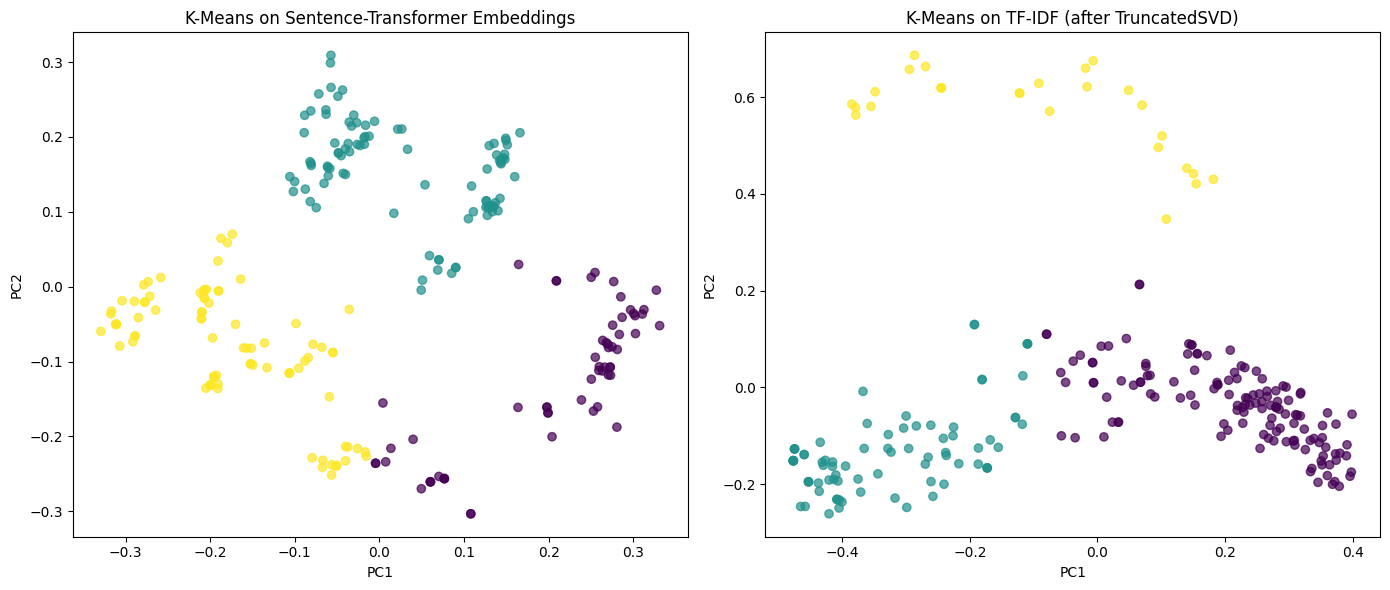

Cross-tabulation: Embedding clusters vs TF-IDF clusters
TF-IDF Cluster      0   1   2
Embedding Cluster            
0                  41  11   8
1                  84   0  10
2                   9  68   9


In [7]:
# -----------------------------------------------------------
# Part 3: Cluster on embeddings and compare to TF-IDF
# -----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer

# -----------------------------------------------------------
# Step A: K-Means on sentence-transformer embeddings (K=3)
# -----------------------------------------------------------
kmeans_emb = KMeans(n_clusters=3, random_state=42, n_init=10)
fomc_df['cluster_emb'] = kmeans_emb.fit_predict(embeddings)

print('Embedding cluster counts:')
print(fomc_df['cluster_emb'].value_counts().sort_index())
print()

# -----------------------------------------------------------
# Step B: K-Means on corrected TF-IDF
# -----------------------------------------------------------
# If tfidf_matrix from Part 2 already exists, use it.
# Otherwise create it again here.

try:
    tfidf_matrix_corrected = tfidf_matrix
except NameError:
    tfidf_corrected = TfidfVectorizer(
        min_df=5,
        max_df=0.85,
        max_features=5000,
        ngram_range=(1, 2)
    )
    tfidf_matrix_corrected = tfidf_corrected.fit_transform(fomc_df['clean_text'])

# Reduce TF-IDF to 50 dimensions before clustering
svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix_corrected)

kmeans_tfidf = KMeans(n_clusters=3, random_state=42, n_init=10)
fomc_df['cluster_tfidf'] = kmeans_tfidf.fit_predict(tfidf_reduced)

print('TF-IDF cluster counts:')
print(fomc_df['cluster_tfidf'].value_counts().sort_index())
print()

# -----------------------------------------------------------
# Step C: Compare silhouette scores
# -----------------------------------------------------------
sil_emb = silhouette_score(embeddings, fomc_df['cluster_emb'])
sil_tfidf = silhouette_score(tfidf_reduced, fomc_df['cluster_tfidf'])

print(f'Silhouette — Embeddings: {sil_emb:.3f}')
print(f'Silhouette — TF-IDF:     {sil_tfidf:.3f}')
print()

if sil_emb > sil_tfidf:
    print('Embeddings produce better-separated clusters based on silhouette score.')
elif sil_tfidf > sil_emb:
    print('TF-IDF produces better-separated clusters based on silhouette score.')
else:
    print('Both methods produce the same silhouette score.')

print()

# -----------------------------------------------------------
# Step D: Visualize both clusterings side by side in PCA space
# -----------------------------------------------------------

# PCA for embeddings
pca_emb = PCA(n_components=2, random_state=42)
emb_2d = pca_emb.fit_transform(embeddings)

# PCA for reduced TF-IDF
pca_tfidf = PCA(n_components=2, random_state=42)
tfidf_2d = pca_tfidf.fit_transform(tfidf_reduced)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: embeddings clusters
scatter1 = axes[0].scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=fomc_df['cluster_emb'],
    alpha=0.7
)
axes[0].set_title('K-Means on Sentence-Transformer Embeddings')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Right: TF-IDF clusters
scatter2 = axes[1].scatter(
    tfidf_2d[:, 0],
    tfidf_2d[:, 1],
    c=fomc_df['cluster_tfidf'],
    alpha=0.7
)
axes[1].set_title('K-Means on TF-IDF (after TruncatedSVD)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Optional: cross-tab comparison
# -----------------------------------------------------------
print('Cross-tabulation: Embedding clusters vs TF-IDF clusters')
print(pd.crosstab(
    fomc_df['cluster_emb'],
    fomc_df['cluster_tfidf'],
    rownames=['Embedding Cluster'],
    colnames=['TF-IDF Cluster']
))

In [8]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

def evaluate_timeseries_auc(X, y, model_name):
    tscv = TimeSeriesSplit(n_splits=5)
    auc_scores = []

    print(f'=== {model_name} ===')

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        train_classes = np.unique(y_train)
        test_classes = np.unique(y_test)

        # Check whether both train and test contain 2 classes
        if len(train_classes) < 2:
            print(f'Fold {fold}: skipped (training set has only one class: {train_classes})')
            continue

        if len(test_classes) < 2:
            print(f'Fold {fold}: skipped (test set has only one class: {test_classes})')
            continue

        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
        auc_scores.append(auc)

        print(f'Fold {fold}: AUC-ROC = {auc:.3f}')

    if len(auc_scores) == 0:
        print('No valid folds were available for AUC evaluation.')
        return []

    print(f'Mean AUC-ROC: {np.mean(auc_scores):.3f}')
    print(f'Std AUC-ROC:  {np.std(auc_scores):.3f}')
    print()

    return auc_scores

---

## Part 4: Module Output — `fomc_sentiment.py`

Write a reusable Python module for FOMC text analysis.
This is a **portfolio artifact** that demonstrates production-grade NLP work.

### Requirements

```python
# src/fomc_sentiment.py

def preprocess_fomc(text: str) -> str:
    """Clean and tokenize FOMC minutes text.
    
    Steps: lowercase, regex clean, word_tokenize, stop words, lemmatize.
    Returns space-joined clean tokens.
    """
    ...

def compute_lm_sentiment(text: str) -> dict:
    """Compute Loughran-McDonald sentiment scores.
    
    Returns dict with 'net_sentiment', 'uncertainty',
    'neg_count', 'pos_count', 'unc_count', 'total_words'.
    """
    ...

def build_tfidf_matrix(texts: list, min_df=5, max_df=0.85,
                       max_features=5000) -> tuple:
    """Build TF-IDF matrix from preprocessed texts.
    
    Returns (sparse_matrix, feature_names, vectorizer).
    """
    ...
```

In [9]:
# -----------------------------------------------------------
# src/fomc_sentiment.py
# Reusable module for FOMC text analysis
# -----------------------------------------------------------

import re
import nltk
import numpy as np
from typing import List, Tuple, Dict

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

# -----------------------------------------------------------
# Download required NLTK resources
# -----------------------------------------------------------
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# -----------------------------------------------------------
# Global NLP tools
# -----------------------------------------------------------
STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

# -----------------------------------------------------------
# Simplified Loughran-McDonald dictionaries
# -----------------------------------------------------------
LM_NEGATIVE = set([
    'adverse', 'decline', 'deficit', 'difficult', 'downturn',
    'failure', 'fear', 'loss', 'negative', 'pressure',
    'problem', 'recession', 'risk', 'risks', 'slowdown',
    'uncertain', 'uncertainty', 'volatile', 'weak', 'worse'
])

LM_POSITIVE = set([
    'benefit', 'confidence', 'gain', 'growth', 'improve',
    'improvement', 'increase', 'opportunity', 'positive',
    'progress', 'recovery', 'resilient', 'stable',
    'strength', 'strong', 'success'
])

LM_UNCERTAINTY = set([
    'approximate', 'assume', 'contingent', 'depend',
    'estimate', 'likely', 'may', 'might', 'possible',
    'potential', 'uncertain', 'uncertainty', 'varies'
])

# -----------------------------------------------------------
# Function 1: Preprocess text
# -----------------------------------------------------------
def preprocess_fomc(text: str) -> str:
    """
    Clean and tokenize FOMC minutes text.

    Steps:
    1. lowercase
    2. word_tokenize
    3. keep alphabetic tokens only
    4. remove stopwords
    5. remove short words
    6. lemmatize

    Returns:
        Space-joined cleaned tokens
    """

    if not isinstance(text, str):
        return ""

    text = text.lower()
    tokens = word_tokenize(text)

    tokens = [t for t in tokens if re.fullmatch(r'[a-z]+', t)]
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]

    return " ".join(tokens)

# -----------------------------------------------------------
# Function 2: Compute LM sentiment
# -----------------------------------------------------------
def compute_lm_sentiment(text: str) -> Dict:
    """
    Compute Loughran-McDonald style sentiment scores.

    Returns dictionary with:
        net_sentiment
        uncertainty
        neg_count
        pos_count
        unc_count
        total_words
    """

    if not isinstance(text, str) or len(text.strip()) == 0:
        return {
            'net_sentiment': 0,
            'uncertainty': 0,
            'neg_count': 0,
            'pos_count': 0,
            'unc_count': 0,
            'total_words': 0
        }

    tokens = text.split()
    total = len(tokens)

    neg_count = sum(1 for t in tokens if t in LM_NEGATIVE)
    pos_count = sum(1 for t in tokens if t in LM_POSITIVE)
    unc_count = sum(1 for t in tokens if t in LM_UNCERTAINTY)

    net_sentiment = (pos_count - neg_count) / total
    uncertainty = unc_count / total

    return {
        'net_sentiment': net_sentiment,
        'uncertainty': uncertainty,
        'neg_count': neg_count,
        'pos_count': pos_count,
        'unc_count': unc_count,
        'total_words': total
    }

# -----------------------------------------------------------
# Function 3: Build TF-IDF matrix
# -----------------------------------------------------------
def build_tfidf_matrix(
    texts: List[str],
    min_df: int = 5,
    max_df: float = 0.85,
    max_features: int = 5000
) -> Tuple:
    """
    Build TF-IDF matrix from preprocessed texts.

    Parameters:
        texts: list of cleaned text strings
        min_df: minimum document frequency
        max_df: maximum document frequency
        max_features: vocabulary cap

    Returns:
        sparse_matrix, feature_names, vectorizer
    """

    vectorizer = TfidfVectorizer(
        min_df=min_df,
        max_df=max_df,
        max_features=max_features,
        ngram_range=(1, 2)
    )

    matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()

    return matrix, feature_names, vectorizer

# -----------------------------------------------------------
# Function 4: Full pipeline helper
# -----------------------------------------------------------
def analyze_document(text: str) -> Dict:
    """
    Full single-document pipeline:
    preprocess + sentiment

    Returns:
        dictionary with cleaned text + sentiment metrics
    """

    clean_text = preprocess_fomc(text)
    scores = compute_lm_sentiment(clean_text)

    result = {'clean_text': clean_text}
    result.update(scores)

    return result

# -----------------------------------------------------------
# Example usage
# -----------------------------------------------------------
if __name__ == "__main__":

    sample = """
    The committee noted that inflation remained elevated,
    but labor market conditions were strong and growth was stable.
    """

    result = analyze_document(sample)

    print("=== Example Analysis ===")
    for k, v in result.items():
        print(f"{k}: {v}")

=== Example Analysis ===
clean_text: committee noted inflation remained elevated labor market condition strong growth stable
net_sentiment: 0.2727272727272727
uncertainty: 0.0
neg_count: 0
pos_count: 3
unc_count: 0
total_words: 11


In [10]:
## %%writefile src/fomc_sentiment.py
"""
fomc_sentiment.py — FOMC Text Analysis Module

Reusable functions for preprocessing, sentiment scoring, and
TF-IDF vectorization of Federal Reserve meeting minutes.

Author: [Your Name]
Course: ECON 5200, Lab 23
"""

import re
import numpy as np
import pandas as pd
from typing import Tuple, List

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer


# Loughran-McDonald word lists (simplified)
LM_NEGATIVE = set([
    'adverse', 'adversely', 'against', 'concern', 'concerned', 'concerns',
    'decline', 'declined', 'declining', 'decrease', 'decreased', 'deficit',
    'deteriorate', 'deteriorated', 'deteriorating', 'difficult', 'difficulty',
    'downturn', 'fail', 'failure', 'falling', 'loss', 'losses', 'negative',
    'negatively', 'recession', 'recessionary', 'risk', 'risks', 'risky',
    'severe', 'severely', 'slowdown', 'sluggish', 'stress', 'stressed',
    'threat', 'threaten', 'troubled', 'uncertain', 'uncertainty',
    'unfavorable', 'volatile', 'volatility', 'vulnerability', 'vulnerable',
    'weak', 'weaken', 'weakened', 'weakness', 'worse', 'worsen', 'worsened'
])

LM_POSITIVE = set([
    'achieve', 'achieved', 'achievement', 'benefit', 'beneficial', 'confidence',
    'confident', 'favorable', 'gain', 'gained', 'gains', 'good', 'growth',
    'improve', 'improved', 'improvement', 'improving', 'increase', 'increased',
    'opportunity', 'optimism', 'optimistic', 'positive', 'positively',
    'profit', 'profitable', 'progress', 'rebound', 'recover', 'recovery',
    'strength', 'strengthen', 'strong', 'stronger', 'success', 'successful'
])

LM_UNCERTAINTY = set([
    'approximate', 'approximately', 'assume', 'assumption', 'believe',
    'cautious', 'could', 'depend', 'depends', 'doubt', 'estimate',
    'expect', 'expected', 'forecast', 'indefinite', 'likelihood', 'may',
    'might', 'nearly', 'perhaps', 'possible', 'possibly', 'predict',
    'preliminary', 'probable', 'probably', 'risk', 'roughly', 'seem',
    'suggest', 'tentative', 'uncertain', 'uncertainty', 'unclear',
    'unpredictable', 'variable'
])

# Download required NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()


def preprocess_fomc(text: str) -> str:
    """Clean and tokenize FOMC minutes text."""
    if not isinstance(text, str) or pd.isna(text):
        return ""

    text = text.lower()
    tokens = word_tokenize(text)

    # keep alphabetic tokens only
    tokens = [t for t in tokens if re.fullmatch(r"[a-z]+", t)]

    # remove stopwords and short tokens
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

    # lemmatize
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]

    return " ".join(tokens)


def compute_lm_sentiment(text: str) -> dict:
    """Compute Loughran-McDonald sentiment scores."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {
            'net_sentiment': 0.0,
            'uncertainty': 0.0,
            'neg_count': 0,
            'pos_count': 0,
            'unc_count': 0,
            'total_words': 0
        }

    tokens = text.split()
    total_words = len(tokens)

    neg_count = sum(1 for t in tokens if t in LM_NEGATIVE)
    pos_count = sum(1 for t in tokens if t in LM_POSITIVE)
    unc_count = sum(1 for t in tokens if t in LM_UNCERTAINTY)

    net_sentiment = (pos_count - neg_count) / total_words if total_words > 0 else 0.0
    uncertainty = unc_count / total_words if total_words > 0 else 0.0

    return {
        'net_sentiment': net_sentiment,
        'uncertainty': uncertainty,
        'neg_count': neg_count,
        'pos_count': pos_count,
        'unc_count': unc_count,
        'total_words': total_words
    }


def build_tfidf_matrix(
    texts: List[str],
    min_df: int = 5,
    max_df: float = 0.85,
    max_features: int = 5000
) -> Tuple:
    """Build TF-IDF matrix from preprocessed texts."""
    vectorizer = TfidfVectorizer(
        min_df=min_df,
        max_df=max_df,
        max_features=max_features,
        ngram_range=(1, 2)
    )

    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()

    return tfidf_matrix, feature_names, vectorizer


# --- Quick self-test ---
if __name__ == '__main__':
    test_text = "The committee noted that inflation remained elevated above target."
    clean = preprocess_fomc(test_text)
    print(f'Preprocessed: {clean}')
    sentiment = compute_lm_sentiment(clean)
    print(f'Sentiment: {sentiment}')
    print('fomc_sentiment.py loaded successfully.')

Preprocessed: committee noted inflation remained elevated target
Sentiment: {'net_sentiment': 0.0, 'uncertainty': 0.0, 'neg_count': 0, 'pos_count': 0, 'unc_count': 0, 'total_words': 6}
fomc_sentiment.py loaded successfully.


---

## Challenge: Compare TF-IDF vs Embedding Predictive Power

Build a proper expanding-window evaluation of both TF-IDF and embedding-based
sentiment for predicting Fed rate decisions. Use at least 5 splits.
Report mean AUC and standard deviation across folds.

Write a 1-paragraph summary of which representation is better and why.

In [11]:
# -----------------------------------------------------------
# CHALLENGE — Full comparison of TF-IDF vs Embeddings
# -----------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

# -----------------------------------------------------------
# 1. Prepare target
# -----------------------------------------------------------
tightening_years = set([2004, 2005, 2006, 2015, 2016, 2017, 2018, 2022, 2023])
fomc_df = fomc_df.sort_values('date').reset_index(drop=True)
fomc_df['tightening'] = fomc_df['year'].isin(tightening_years).astype(int)

y = fomc_df['tightening'].values

print(f'Total documents: {len(fomc_df)}')
print(f'Tightening meetings: {fomc_df['tightening'].sum()}')
print(f'Easing/holding meetings: {(1 - fomc_df['tightening']).sum()}')
print()

# -----------------------------------------------------------
# 2. Prepare TF-IDF features
# -----------------------------------------------------------
try:
    tfidf_matrix_corrected = tfidf_matrix
except NameError:
    tfidf_vectorizer = TfidfVectorizer(
        min_df=5,
        max_df=0.85,
        max_features=5000,
        ngram_range=(1, 2)
    )
    tfidf_matrix_corrected = tfidf_vectorizer.fit_transform(fomc_df['clean_text'])

svd = TruncatedSVD(n_components=50, random_state=42)
X_tfidf = svd.fit_transform(tfidf_matrix_corrected)

# -----------------------------------------------------------
# 3. Prepare embedding features
# -----------------------------------------------------------
X_emb = embeddings

print('TF-IDF reduced shape:', X_tfidf.shape)
print('Embedding shape:', X_emb.shape)
print()

# -----------------------------------------------------------
# 4. Expanding-window evaluation
# -----------------------------------------------------------
def expanding_window_auc(X, y, model_name, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    auc_scores = []

    print(f'=== {model_name} ===')

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        train_classes = np.unique(y_train)
        test_classes = np.unique(y_test)

        print(f'Fold {fold}: train={len(train_idx)} obs, test={len(test_idx)} obs')

        if len(train_classes) < 2:
            print(f'  skipped: training set has only one class {train_classes}')
            continue

        if len(test_classes) < 2:
            print(f'  skipped: test set has only one class {test_classes}')
            continue

        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
        auc_scores.append(auc)

        print(f'  AUC-ROC = {auc:.3f}')

    if len(auc_scores) == 0:
        print('No valid folds available.\n')
        return []

    print(f'Mean AUC-ROC: {np.mean(auc_scores):.3f}')
    print(f'Std AUC-ROC:  {np.std(auc_scores):.3f}')
    print()

    return auc_scores

# -----------------------------------------------------------
# 5. Evaluate both representations
# -----------------------------------------------------------
auc_tfidf = expanding_window_auc(X_tfidf, y, 'TF-IDF (50-dim SVD)', n_splits=5)
auc_emb = expanding_window_auc(X_emb, y, 'Embeddings', n_splits=5)

# -----------------------------------------------------------
# 6. Final summary
# -----------------------------------------------------------
tfidf_mean = np.mean(auc_tfidf) if len(auc_tfidf) > 0 else np.nan
tfidf_std = np.std(auc_tfidf) if len(auc_tfidf) > 0 else np.nan

emb_mean = np.mean(auc_emb) if len(auc_emb) > 0 else np.nan
emb_std = np.std(auc_emb) if len(auc_emb) > 0 else np.nan

print('==================================================')
print(f'TF-IDF AUC:      {tfidf_mean:.3f} ± {tfidf_std:.3f} (mean ± std across valid folds)')
print(f'Embeddings AUC:  {emb_mean:.3f} ± {emb_std:.3f} (mean ± std across valid folds)')

if np.isnan(tfidf_mean) and np.isnan(emb_mean):
    winner = 'No valid comparison'
elif np.isnan(tfidf_mean):
    winner = 'Embeddings'
elif np.isnan(emb_mean):
    winner = 'TF-IDF'
elif emb_mean > tfidf_mean:
    winner = 'Embeddings'
elif tfidf_mean > emb_mean:
    winner = 'TF-IDF'
else:
    winner = 'Tie'

print(f'Winner: {winner}')
print('==================================================')

# -----------------------------------------------------------
# 7. Save fold-level results
# -----------------------------------------------------------
results_df = pd.DataFrame({
    'fold': range(1, max(len(auc_tfidf), len(auc_emb)) + 1),
    'tfidf_auc': pd.Series(auc_tfidf),
    'embedding_auc': pd.Series(auc_emb)
})

print()
print(results_df)

Total documents: 240
Tightening meetings: 72
Easing/holding meetings: 168

TF-IDF reduced shape: (240, 50)
Embedding shape: (240, 384)

=== TF-IDF (50-dim SVD) ===
Fold 1: train=40 obs, test=40 obs
  skipped: training set has only one class [0]
Fold 2: train=80 obs, test=40 obs
  skipped: test set has only one class [0]
Fold 3: train=120 obs, test=40 obs
  AUC-ROC = 0.952
Fold 4: train=160 obs, test=40 obs
  AUC-ROC = 0.990
Fold 5: train=200 obs, test=40 obs
  AUC-ROC = 0.513
Mean AUC-ROC: 0.818
Std AUC-ROC:  0.217

=== Embeddings ===
Fold 1: train=40 obs, test=40 obs
  skipped: training set has only one class [0]
Fold 2: train=80 obs, test=40 obs
  skipped: test set has only one class [0]
Fold 3: train=120 obs, test=40 obs
  AUC-ROC = 0.997
Fold 4: train=160 obs, test=40 obs
  AUC-ROC = 0.678
Fold 5: train=200 obs, test=40 obs
  AUC-ROC = 0.487
Mean AUC-ROC: 0.721
Std AUC-ROC:  0.210

TF-IDF AUC:      0.818 ± 0.217 (mean ± std across valid folds)
Embeddings AUC:  0.721 ± 0.210 (mean ±